In [15]:
import rasterio
import numpy as np

y = 2025
for m in range(1,9):
    spi_file = f"/Users/cherryleheu/Documents/HCDP/Data/monthly/SPI/spi3_{y}_{m:02d}.tif"
    outfile = f"/Users/cherryleheu/Documents/HCDP/Data/monthly/drought_category/spi3_{y}_{m:02d}_category.tif"

    with rasterio.open(spi_file) as src:
        data = src.read(1)
        profile = src.profile

    categorical = np.full_like(data, 255, dtype=np.uint8)  # start with nodata=255

    categorical[data <= -2.0] = 0
    categorical[(data > -2.0) & (data <= -1.6)] = 1
    categorical[(data > -1.6) & (data <= -1.3)] = 2
    categorical[(data > -1.3) & (data <= -0.8)] = 3
    categorical[(data > -0.8) & (data <= -0.5)] = 4
    categorical[(data > -0.5) & (data < 0.5)] = 5
    categorical[(data >= 0.5) & (data < 0.8)] = 6
    categorical[(data >= 0.8) & (data < 1.3)] = 7
    categorical[(data >= 1.3) & (data < 1.6)] = 8
    categorical[(data >= 1.6) & (data < 2.0)] = 9
    categorical[data >= 2.0] = 10

    # --- Update profile ---
    profile.update(
        dtype=rasterio.uint8,
        count=1,
        compress='lzw',
        nodata=255
    )

    with rasterio.open(outfile, "w", **profile) as dst:
        dst.write(categorical, 1)


    raster_path = f"/Users/cherryleheu/Documents/HCDP/Data/monthly/drought_category/spi3_{y}_{m:02d}_category.tif"

    with rasterio.open(raster_path) as src:
        data = src.read(1)
        nodata = src.nodata


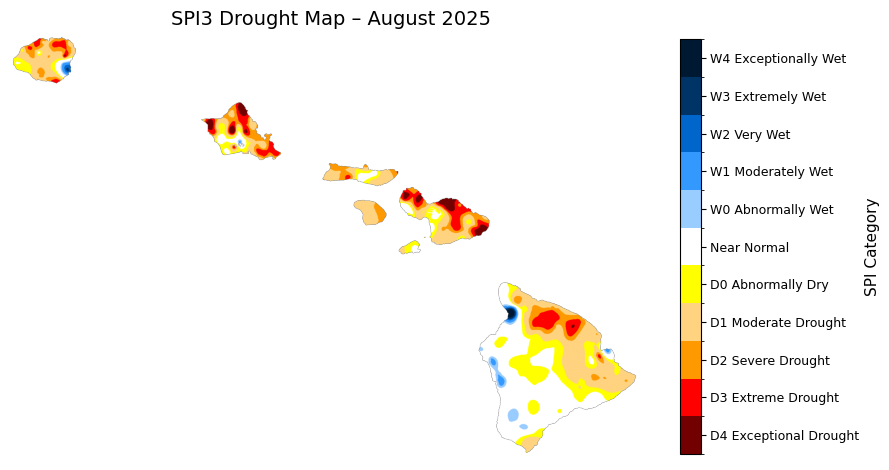

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm


data = np.where(data == nodata, np.nan, data)

colors = [
    "#730000",  # 0 D4 Exceptional Drought
    "#FF0000",  # 1 D3 Extreme Drought
    "#FF9900",  # 2 D2 Severe Drought
    "#FFD37F",  # 3 D1 Moderate Drought
    "#FFFF00",  # 4 D0 Abnormally Dry
    "#FFFFFF",  # 5 Near Normal
    "#99CCFF",  # 6 W0 Abnormally Wet
    "#3399FF",  # 7 W1 Moderately Wet
    "#0066CC",  # 8 W2 Very Wet
    "#003366",  # 9 W3 Extremely Wet
    "#001933",  # 10 W4 Exceptionally Wet
]

labels = [
    "D4 Exceptional Drought",
    "D3 Extreme Drought",
    "D2 Severe Drought",
    "D1 Moderate Drought",
    "D0 Abnormally Dry",
    "Near Normal",
    "W0 Abnormally Wet",
    "W1 Moderately Wet",
    "W2 Very Wet",
    "W3 Extremely Wet",
    "W4 Exceptionally Wet"
]

cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
im = plt.imshow(data, cmap=cmap, norm=norm)
plt.title("SPI3 Drought Map – August 2025", fontsize=14)
plt.axis("off")

cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)
cbar.set_label("SPI Category", fontsize=11)

plt.tight_layout()
plt.show()


In [22]:
import rasterio
import geopandas as gpd
import numpy as np
from rasterstats import zonal_stats
import pandas as pd
import os

# --- Configuration ---
raster_folder = "/Users/cherryleheu/Documents/HCDP/Data/monthly/drought_category"
shapefile = "../public/shapefiles/Coastline.shp"

# --- Load shapefile and dissolve to single feature (statewide) ---
gdf = gpd.read_file(shapefile)
gdf_statewide = gdf.dissolve()  # merges all polygons into one

# --- Category definitions ---
category_ranges = [
    (-np.inf, -2.0),
    (-2.0, -1.6),
    (-1.6, -1.3),
    (-1.3, -0.8),
    (-0.8, -0.5),
    (-0.5, 0.5),
    (0.5, 0.8),
    (0.8, 1.3),
    (1.3, 1.6),
    (1.6, 2.0),
    (2.0, np.inf)
]

# --- Collect results ---
records = []

for year in [2024, 2025]:
    for month in range(1, 13):
        # Skip months outside range
        if year == 2024 and month < 9:
            continue
        if year == 2025 and month > 8:
            break

        tif_path = f"{raster_folder}/spi3_{year}_{month:02d}_category.tif"
        if not os.path.exists(tif_path):
            print(f"Missing file: {tif_path}")
            continue

        with rasterio.open(tif_path) as src:
            data = src.read(1).astype(float)
            nodata = src.nodata

        # Mask nodata and values outside shapefile extent
        data = np.where(data == nodata, np.nan, data)

        # Compute category percentages
        valid = np.isfinite(data)
        total_pixels = np.sum(valid)
        percentages = []

        for cat in range(11):  # 0–10
            count = np.sum(data == cat)
            pct = (count / total_pixels) * 100 if total_pixels > 0 else np.nan
            percentages.append(pct)

        record = {
            "year": year,
            "month": month,
            **{f"cat_{i}": percentages[i] for i in range(11)}
        }
        records.append(record)

# --- Save results ---
df = pd.DataFrame(records)
df["date"] = pd.to_datetime(df[["year", "month"]].assign(day=1))
df = df.sort_values("date")

out_csv = "./spi3_statewide_category_percentages.csv"
# df.to_csv(out_csv, index=False)

print(f"Saved statewide SPI category percentages to {out_csv}")
print(df.head())


Saved statewide SPI category percentages to ./spi3_statewide_category_percentages.csv
   year  month     cat_0      cat_1      cat_2      cat_3      cat_4  \
0  2024      9  2.870656   3.786682   2.152558   4.849592   4.619717   
1  2024     10  0.502460   1.690030   2.289024   6.320512   5.276353   
2  2024     11  1.542513   2.485044   4.649773  16.561864  10.744784   
3  2024     12  4.273516  10.515899  13.210502  19.381005  12.676095   
4  2025      1  0.000000   0.561491   6.059385  15.277638  12.942431   

       cat_5      cat_6      cat_7     cat_8     cat_9    cat_10       date  
0  29.775021  11.687843  23.241650  9.124844  4.927027  2.964411 2024-09-01  
1  27.678370  13.328217  26.589764  8.689749  4.495404  3.140116 2024-10-01  
2  42.830789  16.945408   4.132823  0.098318  0.008685  0.000000 2024-11-01  
3  39.821795   0.121188   0.000000  0.000000  0.000000  0.000000 2024-12-01  
4  45.385318  14.037981   5.164888  0.570867  0.000000  0.000000 2025-01-01  


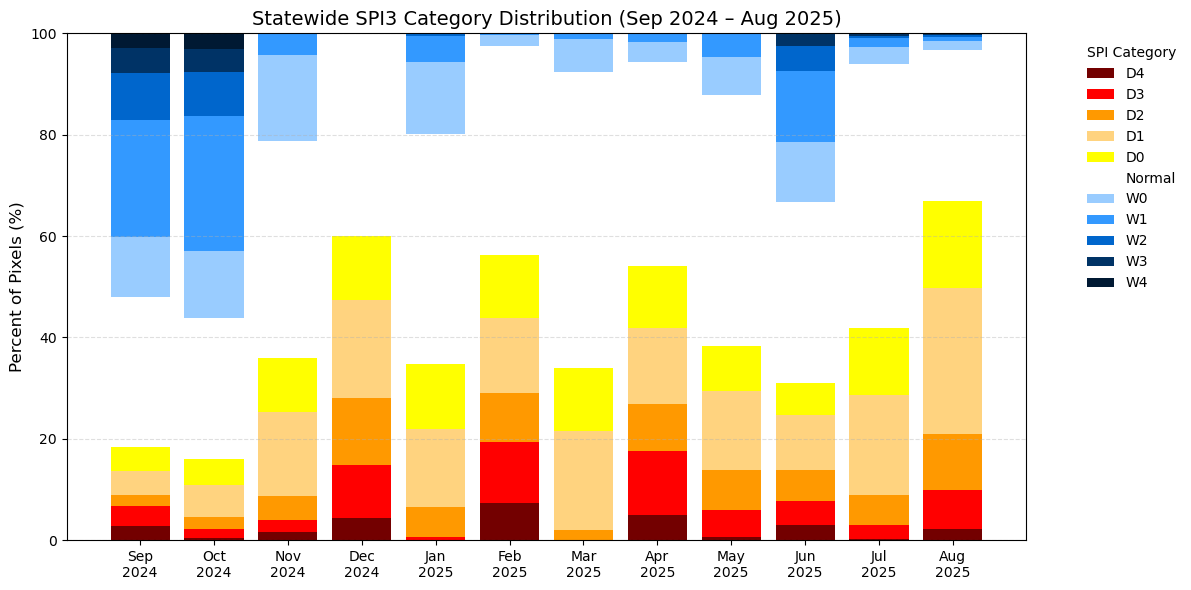

In [21]:
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# --- Config ---
raster_folder = "/Users/cherryleheu/Documents/HCDP/Data/monthly/drought_category"
shapefile = "../public/shapefiles/Coastline.shp"

# --- Load and dissolve shapefile (statewide) ---
gdf = gpd.read_file(shapefile)
gdf_statewide = gdf.dissolve()

# --- Category info ---
categories = list(range(11))
labels = [
    "D4", "D3", "D2", "D1", "D0",
    "Normal",
    "W0", "W1", "W2", "W3", "W4"
]
colors = [
    "#730000", "#FF0000", "#FF9900", "#FFD37F", "#FFFF00",
    "#FFFFFF",
    "#99CCFF", "#3399FF", "#0066CC", "#003366", "#001933"
]

# --- Collect results ---
records = []

for year in [2024, 2025]:
    for month in range(1, 13):
        if year == 2024 and month < 9:
            continue
        if year == 2025 and month > 8:
            break

        tif_path = f"{raster_folder}/spi3_{year}_{month:02d}_category.tif"
        if not os.path.exists(tif_path):
            print(f"Missing file: {tif_path}")
            continue

        with rasterio.open(tif_path) as src:
            data = src.read(1).astype(float)
            nodata = src.nodata

        data = np.where(data == nodata, np.nan, data)
        valid = np.isfinite(data)
        total_pixels = np.sum(valid)

        percentages = []
        for cat in categories:
            count = np.sum(data == cat)
            pct = (count / total_pixels) * 100 if total_pixels > 0 else np.nan
            percentages.append(pct)

        records.append({
            "year": year,
            "month": month,
            **{f"cat_{cat}": percentages[cat] for cat in categories}
        })

# --- Assemble dataframe ---
df = pd.DataFrame(records)
df["date"] = pd.to_datetime(df[["year", "month"]].assign(day=1))
df = df.sort_values("date").reset_index(drop=True)

# --- Prepare for plotting ---
df_plot = df[[f"cat_{c}" for c in categories]]
dates = df["date"].dt.strftime("%b\n%Y")

# --- Plot stacked bar chart ---
fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(df_plot))
for i, cat in enumerate(categories):
    ax.bar(
        dates,
        df_plot[f"cat_{cat}"],
        bottom=bottom,
        color=colors[i],
        label=labels[i],
        width=0.8
    )
    bottom += df_plot[f"cat_{cat}"]

ax.set_ylabel("Percent of Pixels (%)", fontsize=12)
ax.set_title("Statewide SPI3 Category Distribution (Sep 2024 – Aug 2025)", fontsize=14)
ax.legend(
    title="SPI Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False
)
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [27]:
import os
import glob
import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd
from rasterstats import zonal_stats

def get_spi_category_stats(division="climate_divisions"):
    """
    Compute percentage of pixels in each SPI category (0–10)
    for each feature in a division shapefile, across all months
    from 2024-09 through 2025-08.
    """
    print(f"\n--- Processing {division} (SPI Categories) ---")

    # --- Paths ---
    shapefile = f"../public/shapefiles/{division}.shp"
    raster_folder = "/Users/cherryleheu/Documents/HCDP/Data/monthly/drought_category/"
    out_csv = f"../public/{division}_spi3_category_stats.csv"

    # --- Load shapefile ---
    gdf = gpd.read_file(shapefile).copy()
    island_col = next(
        (c for c in gdf.columns if c.lower() in ["island", "mokupuni", "isle", "islandname"]),
        None
    )
    name_col = next(
        (c for c in gdf.columns if c.lower() in ["name", "division", "moku", "climate_div", "ahupuaa", "county"]),
        None
    )

    # --- Build division_full name like "Hawaiʻi::Hilo" ---
    if island_col and name_col:
        gdf["division_full"] = gdf[island_col].astype(str) + "::" + gdf[name_col].astype(str)
        gdf = gdf.dissolve(by="division_full", as_index=False)
    elif name_col:
        gdf["division_full"] = gdf[name_col].astype(str)
        gdf = gdf.dissolve(by="division_full", as_index=False)
    else:
        raise ValueError("No valid island or name column found in shapefile.")

    # --- Category indices (0–10) ---
    categories = list(range(11))

    # --- Gather stats for each month ---
    all_records = []

    for year in [2024, 2025]:
        for month in range(1, 13):
            if year == 2024 and month < 9:
                continue
            if year == 2025 and month > 8:
                break

            tif_path = os.path.join(raster_folder, f"spi3_{year}_{month:02d}_category.tif")
            if not os.path.exists(tif_path):
                print(f"Missing file: {tif_path}")
                continue

            with rasterio.open(tif_path) as src:
                nodata = src.nodata

            zs = zonal_stats(
                gdf,
                tif_path,
                categorical=True,
                nodata=nodata
            )

            for i, stats in enumerate(zs):
                division_name = gdf.iloc[i]["division_full"]
                total = sum(stats.values())
                record = {
                    "year": year,
                    "month": month,
                    "date": f"{year}-{month:02d}",
                    "division_full": division_name,
                }
                for c in categories:
                    count = stats.get(c, 0)
                    pct = (count / total) * 100 if total > 0 else np.nan
                    record[f"cat_{c}"] = pct
                all_records.append(record)

    # --- Combine and export ---
    df = pd.DataFrame(all_records)
    df = df.sort_values(["division_full", "year", "month"])
    df.to_csv(out_csv, index=False)
    print(f"Saved SPI category stats → {out_csv}")


In [28]:
get_spi_category_stats("climate")
get_spi_category_stats("moku")
get_spi_category_stats("ahupuaa")
get_spi_category_stats("watershed")


--- Processing climate (SPI Categories) ---
Saved SPI category stats → ../public/climate_spi3_category_stats.csv

--- Processing moku (SPI Categories) ---
Saved SPI category stats → ../public/moku_spi3_category_stats.csv

--- Processing ahupuaa (SPI Categories) ---
Saved SPI category stats → ../public/ahupuaa_spi3_category_stats.csv

--- Processing watershed (SPI Categories) ---
Saved SPI category stats → ../public/watershed_spi3_category_stats.csv
